# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [56]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Derek Alcala García"            # Tu nombre completo
MATRICULA = "82395"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "alcohol"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Derek Alcala García
Matrícula: 82395
Dataset asignado: alcohol


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [57]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\Derek\AppData\Local\Programs\Python\Python314\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: alcohol
Descripcion: Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio (%)


In [59]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [60]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,2.034725
1,Afghanistan,AFG,2001,2.032329
2,Afghanistan,AFG,2002,2.033833
3,Afghanistan,AFG,2003,2.034417
4,Afghanistan,AFG,2004,2.035337
5,Afghanistan,AFG,2005,2.034475
6,Afghanistan,AFG,2006,2.038559
7,Afghanistan,AFG,2007,2.029229
8,Afghanistan,AFG,2008,2.022360
9,Afghanistan,AFG,2009,2.018910


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [61]:
# Forma del dataset (filas, columnas)
df.shape


(3929, 4)

In [62]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3929 non-null   str    
 1   code    3929 non-null   str    
 2   year    3929 non-null   int64  
 3   valor   3929 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 122.9 KB


In [63]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3929.000000
mean       42.460783
std        24.126328
min         0.830784
25%        24.925045
50%        42.829540
75%        62.844517
max        85.056270
Name: valor, dtype: float64

In [64]:
df.tail(10)

,entity,code,year,valor
3919,Zimbabwe,ZWE,2011,20.971020
3920,Zimbabwe,ZWE,2012,22.023384
3921,Zimbabwe,ZWE,2013,21.848583
3922,Zimbabwe,ZWE,2014,21.441263
3923,Zimbabwe,ZWE,2015,21.239231
3924,Zimbabwe,ZWE,2016,20.903112
3925,Zimbabwe,ZWE,2017,20.388180
3926,Zimbabwe,ZWE,2018,20.949510
3927,Zimbabwe,ZWE,2019,21.365200
3928,Zimbabwe,ZWE,2020,19.353420


In [65]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity    0
code      0
year      0
valor     0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

No se detectan datos mulos, las muestras de los paises abarcan desde el año 2000 hasta el 2020 mostrando el porcentaje de adultos que han tomado alchol durante el ultimo año

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [66]:
# Pregunta 1

df_paises = df[df[config['filtro_paises']].notna()]

# Número de países distintos
n_paises = df_paises['entity'].nunique()
print(f"Número de países distintos: {n_paises}")

# Usar el año más reciente con datos disponibles
anio_reciente = df_paises.dropna(subset=['valor'])['year'].max()
df_reciente = df_paises[df_paises['year'] == anio_reciente].dropna(subset=['valor'])
print(f"Año utilizado para el ranking: {anio_reciente}\n")

# Top 10 países con MAYOR porcentaje de consumo de alcohol
top10_mayor = df_reciente.nlargest(10, 'valor')[['entity', 'year', 'valor']]
print("--- Top 10 países con MAYOR consumo de alcohol (%) ---")
print(top10_mayor.to_string(index=False))

# Top 10 países con MENOR porcentaje de consumo de alcohol
top10_menor = df_reciente.nsmallest(10, 'valor')[['entity', 'year', 'valor']]
print("\n--- Top 10 países con MENOR consumo de alcohol (%) ---")
print(top10_menor.to_string(index=False))


Número de países distintos: 189
Año utilizado para el ranking: 2020

--- Top 10 países con MAYOR consumo de alcohol (%) ---
     entity  year     valor
 Luxembourg  2020 84.195100
    Ireland  2020 83.209274
    Andorra  2020 82.505775
  Australia  2020 80.670130
New Zealand  2020 80.278630
Switzerland  2020 79.957200
    Austria  2020 79.401760
    Iceland  2020 79.204660
    Germany  2020 78.830920
    Denmark  2020 78.287570

--- Top 10 países con MENOR consumo de alcohol (%) ---
      entity  year    valor
      Kuwait  2020 0.830784
     Somalia  2020 0.922955
     Comoros  2020 0.952743
       Yemen  2020 1.152923
       Libya  2020 1.258470
       Syria  2020 1.496604
        Iran  2020 1.545203
    Pakistan  2020 1.574980
  Mauritania  2020 1.743128
Saudi Arabia  2020 1.869912


**Interpretación:**

Se ve una clara diferenica entre los 10 mayores y 10 menores esto se puede atribuir como un primer factor a la cultura ya que los que mas toman son principalmente paises europeos donde se tienen una cultura muy fuerte con el alchol a diferencia de los paises que menos toman donde incluso se puede considerar pecado ya que en oriente la religion que predomina es la musulmana. Otro factor que puede influir es la economia y turimso ya que los paises que estan mas abajo en el top no reciben la misma cantidad de turimso que los paises que estan mas arriba

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [67]:
# Pregunta 2
mexico  = df_paises[df_paises['entity'] == 'Mexico']
alemania = df_paises[df_paises['entity'] == 'Germany']

# Rango común de años
anio_inicio = max(mexico['year'].min(), alemania['year'].min())
anio_fin    = min(mexico['year'].max(), alemania['year'].max())
print(f"Rango común de años: {anio_inicio} – {anio_fin}")

# Filtrar por rango común
mexico_filtrado  = mexico[(mexico['year'] >= anio_inicio) & (mexico['year'] <= anio_fin)]
alemania_filtrado = alemania[(alemania['year'] >= anio_inicio) & (alemania['year'] <= anio_fin)]

# Tabla comparativa con merge (NB03 celdas 46-47)
comparativa = pd.merge(
    mexico_filtrado[['year', 'valor']],
    alemania_filtrado[['year', 'valor']],
    on='year',
    suffixes=('_Mexico', '_Alemania')
)

print(f"\nComparativa México vs Alemania ({anio_inicio}–{anio_fin}):")
print(comparativa.to_string(index=False))


Rango común de años: 2000 – 2020

Comparativa México vs Alemania (2000–2020):
 year  valor_Mexico  valor_Alemania
 2000     43.696823       79.264520
 2001     43.486710       79.021740
 2002     43.310062       78.862880
 2003     43.456112       78.604610
 2004     43.573890       78.549034
 2005     43.666603       78.363940
 2006     44.073420       78.511380
 2007     42.525486       78.469210
 2008     42.630943       78.513140
 2009     42.772570       78.217540
 2010     42.275200       78.340805
 2011     42.341488       78.795494
 2012     42.171944       78.722330
 2013     41.940746       78.817345
 2014     42.286865       78.857130
 2015     42.922820       78.748020
 2016     43.080498       78.920930
 2017     43.575916       79.206490
 2018     43.875687       79.313120
 2019     43.971450       79.135445
 2020     42.036960       78.830920


**Interpretación:**

Tanto Mexico como Alemania no han tenido un gran cambio en cuanto el consumo ya sea para mayor o menor, sin embargo es claro ver como el porcentaje en alemania se dispara en comparacion a Mexico, esto se debe a la cultura de la cerveza que manejan en almeania y como es que no es solo una parte importante de su economia sino que tambien se volvio un elemento cultural de alta importancia.

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [68]:
# Pregunta 3
paises_seleccionados = (
    (df_paises['entity'] == 'United States') |  # América
    (df_paises['entity'] == 'Italy')         |  # Europa
    (df_paises['entity'] == 'Japan')         |  # Asia
    (df_paises['entity'] == 'Algeria')       |  # África
    (df_paises['entity'] == 'Australia')         # Oceanía
)

df_5paises = df_paises[paises_seleccionados]

# Año más reciente con datos disponibles
anio_reciente = df_5paises.dropna(subset=['valor'])['year'].max()
df_comparacion = df_5paises[df_5paises['year'] == anio_reciente].dropna(subset=['valor'])

# Ordenar de mayor a menor
df_comparacion = df_comparacion[['entity', 'year', 'valor']].sort_values('valor', ascending=False)
print(f"Comparación en el año {anio_reciente}:\n")
print(df_comparacion.to_string(index=False))

# País con mayor y menor valor
mayor = df_comparacion.iloc[0]
menor = df_comparacion.iloc[-1]
diferencia = mayor['valor'] - menor['valor']

print(f"\nMayor valor: {mayor['entity']} ({mayor['valor']:.2f}%)")
print(f"Menor valor: {menor['entity']} ({menor['valor']:.2f}%)")
print(f"Diferencia:  {diferencia:.2f}%")


Comparación en el año 2020:

       entity  year     valor
    Australia  2020 80.670130
        Italy  2020 73.213420
United States  2020 71.144690
        Japan  2020 67.500060
      Algeria  2020  7.899352

Mayor valor: Australia (80.67%)
Menor valor: Algeria (7.90%)
Diferencia:  72.77%


**Interpretación:**

Se ve como en Argelia al ser un pais principalemten musulman su consumo de alchol es increiblemente bajo a comparacion de otros paises como australia o italia, ademas del claro factor religioso se puede ver como los demas paises de otros contientntes tienen un consumo mas alto, esto se puede dar tanto por su economia o cultura mas libre

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [69]:
# Pregunta 4
# Año más reciente con datos disponibles
anio_reciente = df_paises.dropna(subset=['valor'])['year'].max()
df_reciente = df_paises[df_paises['year'] == anio_reciente].dropna(subset=['valor'])

# Definir grupos
grupo_latam = df_reciente[
    (df_reciente['entity'] == 'Mexico') |
    (df_reciente['entity'] == 'Colombia') |
    (df_reciente['entity'] == 'Argentina')
]

grupo_asia = df_reciente[
    (df_reciente['entity'] == 'China') |
    (df_reciente['entity'] == 'Japan') |
    (df_reciente['entity'] == 'Vietnam')
]

# Verificar que todos los países tienen datos
print("Latinoamérica:")
print(grupo_latam[['entity', 'valor']].to_string(index=False))

print("\nAsia:")
print(grupo_asia[['entity', 'valor']].to_string(index=False))

# Calcular promedio con numpy (NB03 celda 19)
promedio_latam = np.mean(grupo_latam['valor'].to_numpy())
promedio_asia  = np.mean(grupo_asia['valor'].to_numpy())

print(f"\nPromedio Latinoamérica: {promedio_latam:.2f}%")
print(f"Promedio Asia:          {promedio_asia:.2f}%")


Latinoamérica:
   entity     valor
Argentina 71.019600
 Colombia 40.875217
   Mexico 42.036960

Asia:
 entity     valor
  China 60.263940
  Japan 67.500060
Vietnam 53.704433

Promedio Latinoamérica: 51.31%
Promedio Asia:          60.49%


**Interpretación:**

En asia se suele consumir mas alcohol que en latinoamerica a exepecion de Argentina, donde su consumo se ve disparado por encima de los paises de asia, sin embargo promediando con mexico y colombia que tienen un porcentaje mas bajo provoca que asia aun tenga un mayor promedio 

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [70]:
# Pregunta 5
venezuela = df_paises[df_paises['entity'] == 'Venezuela'].dropna(subset=['valor'])
venezuela = venezuela.sort_values('year')

print(f"Rango de años disponible: {venezuela['year'].min()} – {venezuela['year'].max()}")
print(f"Total de registros: {venezuela.shape[0]}\n")

# Convertir a numpy para estadísticas (NB03 celda 14)
anios   = venezuela['year'].to_numpy()
valores = venezuela['valor'].to_numpy()

# Año con valor máximo y mínimo (NB03 celda 19)
val_max = np.max(valores)
val_min = np.min(valores)

anio_max = venezuela[venezuela['valor'] == val_max].iloc[0]['year']
anio_min = venezuela[venezuela['valor'] == val_min].iloc[0]['year']

print(f"Valor máximo: {val_max:.2f}% en {anio_max}")
print(f"Valor mínimo: {val_min:.2f}% en {anio_min}")

# Tendencia: comparar primer y último valor
primer_valor = venezuela.iloc[0]['valor']
ultimo_valor  = venezuela.iloc[-1]['valor']
cambio = ultimo_valor - primer_valor

print(f"\nPrimer año ({venezuela.iloc[0]['year']}): {primer_valor:.2f}%")
print(f"Último año  ({venezuela.iloc[-1]['year']}): {ultimo_valor:.2f}%")
print(f"Cambio total: {cambio:+.2f}%")

if cambio > 1:
    tendencia = "creciente"
elif cambio < -1:
    tendencia = "decreciente"
else:
    tendencia = "fluctuante (sin cambio significativo)"

print(f"Tendencia general: {tendencia}")


Rango de años disponible: 2000 – 2020
Total de registros: 21

Valor máximo: 49.04% en 2007
Valor mínimo: 36.56% en 2020

Primer año (2000): 47.52%
Último año  (2020): 36.56%
Cambio total: -10.96%
Tendencia general: decreciente


**Interpretación:**

En venezuela se ve una bajada de casi un 11% respecto al inicio, esto se puede deber a las fechas en la que su economia fue mas delicada provocando que las personas debieran de priorizar otras necesidades antes que el consumi de alcohol

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [71]:
# Pregunta 6
mexico = df_paises[df_paises['entity'] == 'Mexico'].dropna(subset=['valor'])
mexico = mexico.sort_values('year')

primer_anio  = mexico.iloc[0]['year']
ultimo_anio  = mexico.iloc[-1]['year']
primer_valor = mexico.iloc[0]['valor']
ultimo_valor = mexico.iloc[-1]['valor']

# Cambio porcentual: ((nuevo - viejo) / viejo) * 100
cambio_pct = ((ultimo_valor - primer_valor) / primer_valor) * 100

print(f"Primer año con datos: {primer_anio} → {primer_valor:.2f}%")
print(f"Último año con datos: {ultimo_anio} → {ultimo_valor:.2f}%")
print(f"\nCambio porcentual: {cambio_pct:+.2f}%")

if cambio_pct > 0:
    print("Resultado: incremento relativo")
else:
    print("Resultado: caída relativa")


Primer año con datos: 2000 → 43.70%
Último año con datos: 2020 → 42.04%

Cambio porcentual: -3.80%
Resultado: caída relativa


**Interpretación:**

El cambio es bastante poco como para poder atribuirle una sola causa probable, puede que en esta epoca mejoraran las campañas de salud dando mas conciencia acerca de los peligros del acohol

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [72]:
# Pregunta 7
# Año más reciente con datos disponibles
anio_reciente = df_paises.dropna(subset=['valor'])['year'].max()
df_reciente = df_paises[df_paises['year'] == anio_reciente].dropna(subset=['valor'])

# Convertir a numpy y calcular estadísticas (NB03 celdas 14 y 19)
valores = df_reciente['valor'].to_numpy()

media    = np.mean(valores)
mediana  = np.median(valores)
desv_std = np.std(valores)

print(f"Año analizado: {anio_reciente}")
print(f"Países con datos: {len(valores)}\n")
print(f"Media:               {media:.2f}%")
print(f"Mediana:             {mediana:.2f}%")
print(f"Desviación estándar: {desv_std:.2f}%")


Año analizado: 2020
Países con datos: 187

Media:               42.25%
Mediana:             42.04%
Desviación estándar: 24.00%


**Interpretación:**

el promedia en el 2020 la media y mediana muestran valores muy similares la unica diferencia es la desviacion estandar la cual probablemente se debe a las diferencias culturales que presentas los paises

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

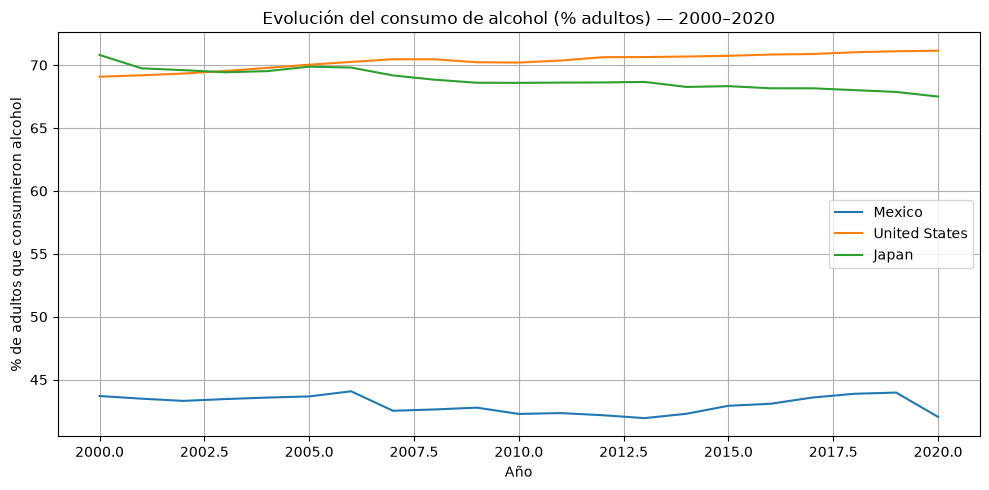

In [73]:
# Pregunta 8
paises_grafica = ['Mexico', 'United States', 'Japan']

plt.figure(figsize=(10, 5))

for pais in paises_grafica:
    datos = df_paises[df_paises['entity'] == pais].dropna(subset=['valor'])
    datos = datos.sort_values('year')
    plt.plot(datos['year'].to_numpy(), datos['valor'].to_numpy(), label=pais)

plt.title("Evolución del consumo de alcohol (% adultos) — 2000–2020")
plt.xlabel("Año")
plt.ylabel("% de adultos que consumieron alcohol")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Interpretación:**

Japon y Estados unidos muestran una mayor cantidad de consumo que mexico, sin embargo se ve una baja tanto en mexico como japon, porbablemente por las nuevas campañas de salud

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

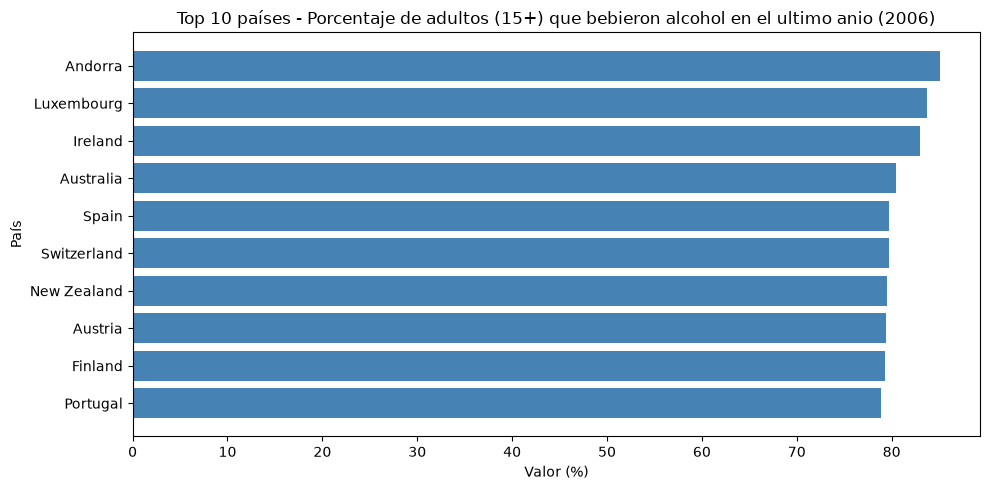

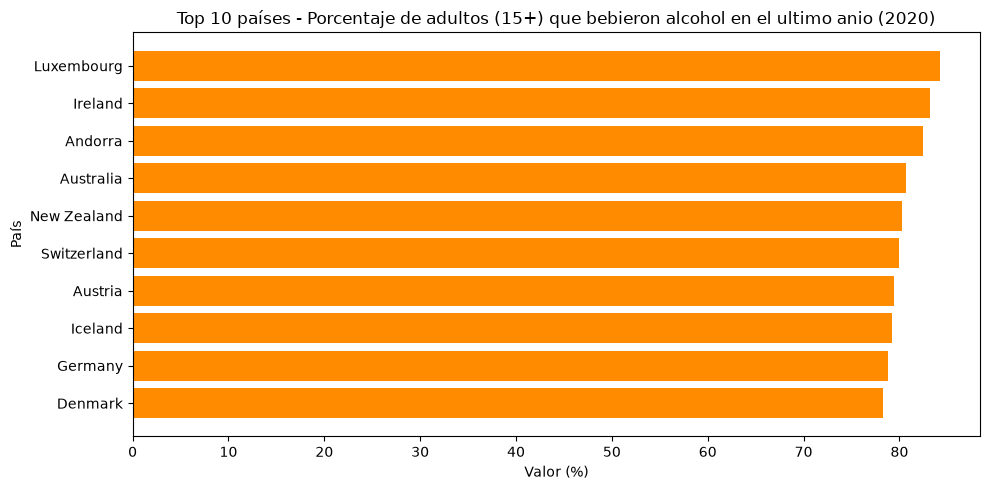

In [74]:
# Pregunta 9
# Gráfica 1 — año de nacimiento (2006)
anio_consultado = 2006

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .dropna(subset=['valor'])
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top 10 países - {config['descripcion']} ({anio_consultado})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Gráfica 2 — año más reciente disponible (2020)
anio_consultado = 2020

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .dropna(subset=['valor'])
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='darkorange')
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top 10 países - {config['descripcion']} ({anio_consultado})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretación:**

Los paises que estan en el top 3 se mantienen a lo largo de los años y una clara dominacion por cultura europea sobre todas las demas, lo que indica una cultura fuerte ligada al alcohol

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

La mayoria de paises en se han mantenido en un puesto o porcentaje similar a lo largo de los años con la exepcion de algunos paises que tuvieron un cambio economico, cultural o religioso. Sin embargo se ha visto una tendencia hacia abajo tal vez por las campañas de salud en varios paises. Entre las limitaicones que se pudieorn encontrar es uqe se limitaba si consumes o no, dejando todo el matiz de poco frecuente y similares fuera. Con mas tiempo tal vez compararia los resultados con el pib o buscando situaciones politicas que se vivieran en ceirtos años



## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
